# NAG-ME-QD: Neural Architecture Generation with MAP-Elites Quality-Diversity

## Fully Self-Contained Research Notebook

This notebook contains the complete NAG-ME-QD system with:
- **Multi-paradigm architecture search**: CNN, Transformer, RNN operations
- **MAP-Elites quality-diversity optimization**: 5D behavior space
- **Three evaluation modes**: Minimal (3 epochs), Zero-shot, Full (25 epochs)
- **Automatic Google Drive backup**: All results saved to Drive
- **ResultsTracker integration**: Standardized output for paper comparison

**Just run all cells - no additional files needed!**

In [1]:
# Mount Google Drive for persistent storage
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/NAS_Comparison_Results'
    IN_COLAB = True
    print("✓ Google Drive mounted successfully")
except:
    OUTPUT_DIR = './NAS_Comparison_Results'
    IN_COLAB = False
    print("ℹ Not in Colab - using local directory")

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

ℹ Not in Colab - using local directory
Output directory: ./NAS_Comparison_Results


---
## 2. Install Dependencies

In [2]:
!pip install -q tqdm matplotlib pandas

---
## 3. Imports & Configuration

In [3]:
import os
import sys
import json
import copy
import math
import time
import random
import logging
import hashlib
import warnings
import traceback
from enum import Enum, auto
from typing import Dict, List, Tuple, Optional, Any, Union, Set
from dataclasses import dataclass, field, asdict
from collections import defaultdict, OrderedDict
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path
import pickle

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torch.nn.utils import clip_grad_norm_

try:
    from tqdm import tqdm, trange
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    def tqdm(iterable, *args, **kwargs):
        return iterable
    def trange(*args, **kwargs):
        return range(*args)

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')

# Device setup
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"TQDM available: {TQDM_AVAILABLE}")
print(f"Torchvision available: {TORCHVISION_AVAILABLE}")

Device: cuda
PyTorch version: 2.9.0+cu126
TQDM available: True
Torchvision available: True


---
## 4. ResultsTracker Class (Standardized Output)

In [4]:
class ResultsTracker:
    """Standardized results tracking for NAS method comparison."""

    def __init__(self, method_name: str, output_dir: str = OUTPUT_DIR):
        self.method_name = method_name
        self.output_dir = output_dir
        self.start_time = time.time()
        self.history = []
        self.best_accuracy = 0.0
        self.best_architecture = None
        self.total_architectures_evaluated = 0
        self.checkpoint_counter = 0

    def log_iteration(self, iteration: int, accuracy: float,
                      architecture: dict = None, extra_metrics: dict = None):
        """Log a single iteration/evaluation."""
        self.total_architectures_evaluated += 1

        entry = {
            'iteration': iteration,
            'accuracy': accuracy,
            'elapsed_time': time.time() - self.start_time,
            'best_so_far': max(self.best_accuracy, accuracy)
        }
        if extra_metrics:
            entry.update(extra_metrics)

        self.history.append(entry)

        if accuracy > self.best_accuracy:
            self.best_accuracy = accuracy
            self.best_architecture = architecture

        # Auto-checkpoint every 50 iterations
        if iteration > 0 and iteration % 50 == 0:
            self._save_checkpoint(iteration)

    def _save_checkpoint(self, iteration: int):
        """Save intermediate checkpoint to Drive."""
        checkpoint = {
            'method': self.method_name,
            'iteration': iteration,
            'best_accuracy': self.best_accuracy,
            'total_evaluated': self.total_architectures_evaluated,
            'elapsed_time': time.time() - self.start_time
        }
        path = os.path.join(self.output_dir, f'{self.method_name}_checkpoint.json')
        with open(path, 'w') as f:
            json.dump(checkpoint, f, indent=2)
        self.checkpoint_counter += 1

    def save_results(self):
        """Save all results to files."""
        total_time = time.time() - self.start_time

        # Full results JSON
        results = {
            'method': self.method_name,
            'best_accuracy': self.best_accuracy,
            'total_search_time_seconds': total_time,
            'total_architectures_evaluated': self.total_architectures_evaluated,
            'best_architecture': self.best_architecture
        }

        with open(os.path.join(self.output_dir, f'{self.method_name}_results.json'), 'w') as f:
            json.dump(results, f, indent=2, default=str)

        # Comparison CSV row
        comparison = pd.DataFrame([{
            'Method': self.method_name,
            'Best_Accuracy': self.best_accuracy,
            'Search_Time_Hours': total_time / 3600,
            'Architectures_Evaluated': self.total_architectures_evaluated
        }])
        comparison.to_csv(os.path.join(self.output_dir, f'{self.method_name}_comparison.csv'), index=False)

        # History JSON
        with open(os.path.join(self.output_dir, f'{self.method_name}_history.json'), 'w') as f:
            json.dump(self.history, f, indent=2)

        print(f"\n{'='*60}")
        print(f"Results saved for {self.method_name}")
        print(f"Best Accuracy: {self.best_accuracy:.4f}")
        print(f"Search Time: {total_time/3600:.2f} hours")
        print(f"Architectures Evaluated: {self.total_architectures_evaluated}")
        print(f"{'='*60}")

        return results

    def plot_convergence(self, save_path: str = None):
        """Plot convergence curve."""
        if not self.history:
            print("No history to plot")
            return

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        iterations = [h['iteration'] for h in self.history]
        accuracies = [h['accuracy'] for h in self.history]
        best_so_far = [h['best_so_far'] for h in self.history]

        # Accuracy over iterations
        axes[0].plot(iterations, accuracies, 'b.', alpha=0.3, label='Individual')
        axes[0].plot(iterations, best_so_far, 'r-', linewidth=2, label='Best so far')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_title(f'{self.method_name} Convergence')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy over time
        times = [h['elapsed_time'] / 60 for h in self.history]  # Convert to minutes
        axes[1].plot(times, best_so_far, 'g-', linewidth=2)
        axes[1].set_xlabel('Time (minutes)')
        axes[1].set_ylabel('Best Accuracy')
        axes[1].set_title(f'{self.method_name} Accuracy vs Time')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(self.output_dir, f'{self.method_name}_plots.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Plot saved to {save_path}")

---
## 5. Core Configuration

In [5]:
@dataclass
class GlobalConfig:
    """Global configuration for the NAG-ME-QD system."""
    output_dir: str = OUTPUT_DIR
    checkpoint_dir: str = os.path.join(OUTPUT_DIR, 'checkpoints')
    log_dir: str = os.path.join(OUTPUT_DIR, 'logs')
    seed: int = 42
    device: str = DEVICE
    grid_resolution: int = 10
    num_iterations: int = 100
    batch_size_eval: int = 32
    max_nodes: int = 8
    max_edges: int = 16
    final_training_epochs: int = 25
    num_workers: int = 2
    log_level: str = "INFO"

    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        os.makedirs(self.log_dir, exist_ok=True)

CONFIG = GlobalConfig()
print(f"Config initialized: {CONFIG}")

Config initialized: GlobalConfig(output_dir='./NAS_Comparison_Results', checkpoint_dir='./NAS_Comparison_Results/checkpoints', log_dir='./NAS_Comparison_Results/logs', seed=42, device='cuda', grid_resolution=10, num_iterations=100, batch_size_eval=32, max_nodes=8, max_edges=16, final_training_epochs=25, num_workers=2, log_level='INFO')


---
## 6. Utility Functions

In [6]:
def set_seed(seed: int = 42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

def cleanup_memory():
    """Clean up GPU memory."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

set_seed(CONFIG.seed)
print("Random seeds set")

Random seeds set


---
## 7. Enums and Data Classes

In [7]:
class CellType(Enum):
    """Types of cells in the architecture."""
    DAG = auto()
    DARTS = auto()
    HYBRID = auto()

class OperationType(Enum):
    """Types of operations."""
    CONV = auto()
    TRANSFORMER = auto()
    RECURRENT = auto()
    IDENTITY = auto()
    ZERO = auto()
    POOLING = auto()

class DatasetType(Enum):
    """Supported datasets."""
    MNIST = auto()
    CIFAR10 = auto()
    CIFAR100 = auto()
    FASHION_MNIST = auto()
    SEQUENTIAL_MNIST = auto()
    TEXT_CLASSIFICATION = auto()

@dataclass
class OperationSpec:
    """Specification for an operation."""
    op_type: OperationType
    kernel_size: int = 3
    stride: int = 1
    padding: int = 1
    dilation: int = 1
    num_heads: int = 4
    hidden_dim: int = 64
    dropout: float = 0.1

    def to_dict(self) -> Dict:
        return {
            'op_type': self.op_type.name,
            'kernel_size': self.kernel_size,
            'stride': self.stride,
            'padding': self.padding,
            'dilation': self.dilation,
            'num_heads': self.num_heads,
            'hidden_dim': self.hidden_dim,
            'dropout': self.dropout
        }

    @classmethod
    def from_dict(cls, d: Dict) -> 'OperationSpec':
        d = d.copy()
        d['op_type'] = OperationType[d['op_type']]
        return cls(**d)

@dataclass
class EdgeSpec:
    """Specification for an edge in the architecture graph."""
    src_node: int
    dst_node: int
    operation: OperationSpec
    weight: float = 1.0

    def to_dict(self) -> Dict:
        return {
            'src_node': self.src_node,
            'dst_node': self.dst_node,
            'operation': self.operation.to_dict(),
            'weight': self.weight
        }

    @classmethod
    def from_dict(cls, d: Dict) -> 'EdgeSpec':
        d = d.copy()
        d['operation'] = OperationSpec.from_dict(d['operation'])
        return cls(**d)

@dataclass
class ArchitectureSpec:
    """Complete architecture specification."""
    cell_type: CellType
    num_nodes: int
    edges: List[EdgeSpec]
    input_channels: int = 3
    num_classes: int = 10
    initial_channels: int = 16
    num_cells: int = 3
    arch_id: str = ""
    creation_time: str = ""

    def __post_init__(self):
        if not self.arch_id:
            self.arch_id = self._generate_id()
        if not self.creation_time:
            self.creation_time = datetime.now().isoformat()

    def _generate_id(self) -> str:
        content = json.dumps(self.to_dict(), sort_keys=True)
        return hashlib.md5(content.encode()).hexdigest()[:12]

    def to_dict(self) -> Dict:
        return {
            'cell_type': self.cell_type.name,
            'num_nodes': self.num_nodes,
            'edges': [e.to_dict() for e in self.edges],
            'input_channels': self.input_channels,
            'num_classes': self.num_classes,
            'initial_channels': self.initial_channels,
            'num_cells': self.num_cells,
            'arch_id': self.arch_id,
            'creation_time': self.creation_time
        }

    @classmethod
    def from_dict(cls, d: Dict) -> 'ArchitectureSpec':
        d = d.copy()
        d['cell_type'] = CellType[d['cell_type']]
        d['edges'] = [EdgeSpec.from_dict(e) for e in d['edges']]
        return cls(**d)

    def get_operation_counts(self) -> Dict[OperationType, int]:
        counts = defaultdict(int)
        for edge in self.edges:
            counts[edge.operation.op_type] += 1
        return dict(counts)

    def get_dominant_operation(self) -> OperationType:
        counts = self.get_operation_counts()
        if not counts:
            return OperationType.CONV
        return max(counts, key=counts.get)

    def get_behavior_descriptor(self) -> Tuple[float, ...]:
        """Compute behavior descriptor for MAP-Elites (5D)."""
        if not self.edges:
            return (0.0, 0.0, 0.0, 0.0, 0.0)

        max_depth = self._compute_max_depth()
        depth_ratio = max_depth / max(self.num_nodes, 1)

        counts = self.get_operation_counts()
        total_ops = sum(counts.values())
        conv_ratio = counts.get(OperationType.CONV, 0) / max(total_ops, 1)
        transformer_ratio = counts.get(OperationType.TRANSFORMER, 0) / max(total_ops, 1)
        recurrent_ratio = counts.get(OperationType.RECURRENT, 0) / max(total_ops, 1)

        max_edges = self.num_nodes * (self.num_nodes - 1) // 2
        connectivity = len(self.edges) / max(max_edges, 1)

        return (depth_ratio, conv_ratio, transformer_ratio, recurrent_ratio, connectivity)

    def _compute_max_depth(self) -> int:
        if not self.edges:
            return 0
        adj = defaultdict(list)
        for edge in self.edges:
            adj[edge.src_node].append(edge.dst_node)

        def dfs(node: int, visited: Set[int]) -> int:
            if node in visited:
                return 0
            visited.add(node)
            max_child_depth = 0
            for child in adj[node]:
                max_child_depth = max(max_child_depth, dfs(child, visited))
            visited.remove(node)
            return 1 + max_child_depth

        max_depth = 0
        for start_node in range(self.num_nodes):
            max_depth = max(max_depth, dfs(start_node, set()))
        return max_depth

print("Data classes defined")

Data classes defined


---
## 8. Neural Network Operations

In [8]:
class AdaptiveChannelLayer(nn.Module):
    """Dynamically adapts channel dimensions."""
    def __init__(self, target_channels: int):
        super().__init__()
        self.target_channels = target_channels
        self.adapters = nn.ModuleDict()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 4:
            current_channels = x.shape[1]
        elif x.dim() == 3:
            current_channels = x.shape[2]
        else:
            return x

        if current_channels == self.target_channels:
            return x

        key = f"adapt_{current_channels}_{self.target_channels}"
        if key not in self.adapters:
            if x.dim() == 4:
                self.adapters[key] = nn.Conv2d(current_channels, self.target_channels, 1).to(x.device)
            else:
                self.adapters[key] = nn.Linear(current_channels, self.target_channels).to(x.device)
        return self.adapters[key](x)

class ConvOperation(nn.Module):
    """Convolutional operation."""
    def __init__(self, in_channels: int, out_channels: int, spec: OperationSpec):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=spec.kernel_size,
                              stride=spec.stride, padding=spec.padding, dilation=spec.dilation, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(spec.dropout)
        self.input_adapter = AdaptiveChannelLayer(in_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            b, l, c = x.shape
            h = w = int(math.ceil(math.sqrt(l)))
            pad_len = h * w - l
            if pad_len > 0:
                x = F.pad(x, (0, 0, 0, pad_len))
            x = x.permute(0, 2, 1).reshape(b, c, h, w)
        if x.shape[1] != self.conv.in_channels:
            x = self.input_adapter(x)
        return self.dropout(self.relu(self.bn(self.conv(x))))

class TransformerOperation(nn.Module):
    """Self-attention transformer block."""
    def __init__(self, embed_dim: int, spec: OperationSpec):
        super().__init__()
        self.embed_dim = embed_dim
        num_heads = spec.num_heads
        while embed_dim % num_heads != 0 and num_heads > 1:
            num_heads -= 1
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=spec.dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, spec.hidden_dim), nn.GELU(), nn.Dropout(spec.dropout),
            nn.Linear(spec.hidden_dim, embed_dim), nn.Dropout(spec.dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.input_adapter = AdaptiveChannelLayer(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        original_shape = x.shape
        if x.dim() == 4:
            b, c, h, w = x.shape
            x = x.flatten(2).permute(0, 2, 1)
        if x.shape[-1] != self.embed_dim:
            x = self.input_adapter(x)
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ffn(x))
        if len(original_shape) == 4:
            x = x.permute(0, 2, 1).reshape(original_shape[0], -1, original_shape[2], original_shape[3])
        return x

class RecurrentOperation(nn.Module):
    """Recurrent (LSTM) operation."""
    def __init__(self, input_dim: int, hidden_dim: int, spec: OperationSpec):
        super().__init__()
        self.input_dim = input_dim
        self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.projection = nn.Linear(hidden_dim * 2, input_dim)
        self.norm = nn.LayerNorm(input_dim)
        self.input_adapter = AdaptiveChannelLayer(input_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        original_shape = x.shape
        if x.dim() == 4:
            b, c, h, w = x.shape
            x = x.flatten(2).permute(0, 2, 1)
        if x.shape[-1] != self.input_dim:
            x = self.input_adapter(x)
        rnn_out, _ = self.rnn(x)
        x = self.norm(self.projection(rnn_out))
        if len(original_shape) == 4:
            x = x.permute(0, 2, 1).reshape(original_shape[0], -1, original_shape[2], original_shape[3])
        return x

class IdentityOperation(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.channels = channels
        self.adapter = AdaptiveChannelLayer(channels)
    def forward(self, x):
        if x.dim() == 4 and x.shape[1] != self.channels:
            return self.adapter(x)
        return x

class ZeroOperation(nn.Module):
    def __init__(self, channels: int): super().__init__()
    def forward(self, x): return torch.zeros_like(x)

class PoolingOperation(nn.Module):
    def __init__(self, channels: int, pool_type: str = 'max', kernel_size: int = 3):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size, stride=1, padding=kernel_size // 2) if pool_type == 'max' else nn.AvgPool2d(kernel_size, stride=1, padding=kernel_size // 2)
        self.adapter = AdaptiveChannelLayer(channels)
        self.channels = channels
    def forward(self, x):
        if x.dim() == 3:
            b, l, c = x.shape
            h = w = int(math.ceil(math.sqrt(l)))
            x = F.pad(x, (0, 0, 0, h*w - l)) if h*w > l else x
            x = x.permute(0, 2, 1).reshape(b, c, h, w)
        if x.shape[1] != self.channels:
            x = self.adapter(x)
        return self.pool(x)

def create_operation(op_spec: OperationSpec, in_channels: int, out_channels: int) -> nn.Module:
    """Factory function to create operations."""
    if op_spec.op_type == OperationType.CONV:
        return ConvOperation(in_channels, out_channels, op_spec)
    elif op_spec.op_type == OperationType.TRANSFORMER:
        return TransformerOperation(out_channels, op_spec)
    elif op_spec.op_type == OperationType.RECURRENT:
        return RecurrentOperation(in_channels, out_channels, op_spec)
    elif op_spec.op_type == OperationType.IDENTITY:
        return IdentityOperation(out_channels)
    elif op_spec.op_type == OperationType.ZERO:
        return ZeroOperation(out_channels)
    elif op_spec.op_type == OperationType.POOLING:
        return PoolingOperation(out_channels)
    return IdentityOperation(out_channels)

print("Operations defined")

Operations defined


---
## 9. Cell Implementations (DAG, DARTS, Hybrid)

In [9]:
class DAGCell(nn.Module):
    """Direct Acyclic Graph cell."""
    def __init__(self, arch_spec: ArchitectureSpec, channels: int):
        super().__init__()
        self.num_nodes = arch_spec.num_nodes
        self.edge_ops = nn.ModuleDict()
        self.node_inputs = defaultdict(list)
        self.edge_weights = {}

        for edge in arch_spec.edges:
            key = f"edge_{edge.src_node}_{edge.dst_node}"
            self.edge_ops[key] = create_operation(edge.operation, channels, channels)
            self.node_inputs[edge.dst_node].append(edge.src_node)
            self.edge_weights[(edge.src_node, edge.dst_node)] = edge.weight

        self.input_proj = nn.Conv2d(channels, channels, 1)
        self.output_combine = nn.Conv2d(channels * self.num_nodes, channels, 1)

    def forward(self, x):
        x = self.input_proj(x)
        node_outputs = {0: x}
        for node_id in range(1, self.num_nodes):
            inputs = []
            for src in self.node_inputs.get(node_id, []):
                if src in node_outputs:
                    key = f"edge_{src}_{node_id}"
                    if key in self.edge_ops:
                        inputs.append(self.edge_weights.get((src, node_id), 1.0) * self.edge_ops[key](node_outputs[src]))
            node_outputs[node_id] = sum(inputs) if inputs else torch.zeros_like(x)
        return self.output_combine(torch.cat([node_outputs.get(i, torch.zeros_like(x)) for i in range(self.num_nodes)], dim=1))

class DARTSCell(nn.Module):
    """DARTS-style cell with continuous relaxation."""
    def __init__(self, arch_spec: ArchitectureSpec, channels: int):
        super().__init__()
        self.num_nodes = arch_spec.num_nodes
        self.op_choices = nn.ModuleDict()
        self.op_types = [OperationSpec(OperationType.CONV, kernel_size=3), OperationSpec(OperationType.CONV, kernel_size=5),
                         OperationSpec(OperationType.POOLING), OperationSpec(OperationType.IDENTITY)]
        self.node_inputs = defaultdict(list)
        self.edge_indices = {}

        for i, edge in enumerate(arch_spec.edges):
            key = f"edge_{edge.src_node}_{edge.dst_node}"
            self.op_choices[key] = nn.ModuleList([create_operation(op, channels, channels) for op in self.op_types])
            self.node_inputs[edge.dst_node].append(edge.src_node)
            self.edge_indices[(edge.src_node, edge.dst_node)] = i

        self.arch_weights = nn.Parameter(torch.randn(len(arch_spec.edges), len(self.op_types)) * 0.001)
        self.input_proj = nn.Conv2d(channels, channels, 1)
        self.output_combine = nn.Conv2d(channels * self.num_nodes, channels, 1)

    def forward(self, x):
        x = self.input_proj(x)
        node_outputs = {0: x}
        weights = F.softmax(self.arch_weights, dim=-1)
        for node_id in range(1, self.num_nodes):
            inputs = []
            for src in self.node_inputs.get(node_id, []):
                if src in node_outputs:
                    key = f"edge_{src}_{node_id}"
                    if key in self.op_choices:
                        idx = self.edge_indices[(src, node_id)]
                        mixed = sum(weights[idx, i] * self.op_choices[key][i](node_outputs[src]) for i in range(len(self.op_types)))
                        inputs.append(mixed)
            node_outputs[node_id] = sum(inputs) if inputs else torch.zeros_like(x)
        return self.output_combine(torch.cat([node_outputs.get(i, torch.zeros_like(x)) for i in range(self.num_nodes)], dim=1))

class HybridCell(nn.Module):
    """Hybrid cell combining DAG flexibility with DARTS relaxation."""
    def __init__(self, arch_spec: ArchitectureSpec, channels: int):
        super().__init__()
        self.num_nodes = arch_spec.num_nodes
        self.edge_ops = nn.ModuleDict()
        self.edge_weights = nn.ParameterDict()
        self.node_inputs = defaultdict(list)

        for edge in arch_spec.edges:
            key = f"edge_{edge.src_node}_{edge.dst_node}"
            self.edge_ops[key] = create_operation(edge.operation, channels, channels)
            self.edge_weights[key] = nn.Parameter(torch.tensor(edge.weight))
            self.node_inputs[edge.dst_node].append(edge.src_node)

        self.input_proj = nn.Conv2d(channels, channels, 1)
        self.output_combine = nn.Conv2d(channels * self.num_nodes, channels, 1)

    def forward(self, x):
        x = self.input_proj(x)
        node_outputs = {0: x}
        for node_id in range(1, self.num_nodes):
            inputs = []
            for src in self.node_inputs.get(node_id, []):
                if src in node_outputs:
                    key = f"edge_{src}_{node_id}"
                    if key in self.edge_ops:
                        try:
                            out = self.edge_ops[key](node_outputs[src])
                            inputs.append(torch.sigmoid(self.edge_weights[key]) * out)
                        except: pass
            node_outputs[node_id] = sum(inputs) if inputs else torch.zeros_like(x)
        return self.output_combine(torch.cat([node_outputs.get(i, torch.zeros_like(x)) for i in range(self.num_nodes)], dim=1))

def create_cell(arch_spec: ArchitectureSpec, channels: int) -> nn.Module:
    if arch_spec.cell_type == CellType.DAG: return DAGCell(arch_spec, channels)
    elif arch_spec.cell_type == CellType.DARTS: return DARTSCell(arch_spec, channels)
    else: return HybridCell(arch_spec, channels)

print("Cells defined")

Cells defined


---
## 10. Complete NAS Network

In [10]:
class NASNetwork(nn.Module):
    """Complete network built from architecture specification."""
    def __init__(self, arch_spec: ArchitectureSpec):
        super().__init__()
        self.arch_spec = arch_spec
        channels = arch_spec.initial_channels

        self.stem = nn.Sequential(
            nn.Conv2d(arch_spec.input_channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True)
        )

        self.cells = nn.ModuleList()
        for i in range(arch_spec.num_cells):
            self.cells.append(create_cell(arch_spec, channels))
            if i % 2 == 1 and i < arch_spec.num_cells - 1:
                self.cells.append(nn.Sequential(
                    nn.Conv2d(channels, channels * 2, 3, stride=2, padding=1),
                    nn.BatchNorm2d(channels * 2), nn.ReLU(inplace=True)
                ))
                channels *= 2

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(channels, arch_spec.num_classes)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        for cell in self.cells:
            try: x = cell(x)
            except: pass
        if x.dim() == 4:
            x = self.global_pool(x).view(x.size(0), -1)
        elif x.dim() == 3:
            x = x.mean(dim=1)
        return self.classifier(x)

    def get_num_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

print("NASNetwork defined")

NASNetwork defined


---
## 11. Dataset Manager

In [11]:
class DatasetManager:
    """Manages dataset loading and preprocessing."""
    def __init__(self, data_dir: str = './data', batch_size: int = 32):
        self.data_dir = data_dir
        self.batch_size = batch_size
        os.makedirs(data_dir, exist_ok=True)

    def get_dataset(self, dataset_type: DatasetType, train: bool = True, subset_size: Optional[int] = None) -> DataLoader:
        if not TORCHVISION_AVAILABLE:
            return self._get_dummy_loader(subset_size or (5000 if train else 1000))

        if dataset_type == DatasetType.CIFAR10:
            if train:
                transform = transforms.Compose([
                    transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                ])
            else:
                transform = transforms.Compose([
                    transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                ])
            dataset = torchvision.datasets.CIFAR10(self.data_dir, train=train, download=True, transform=transform)
        else:
            transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
            dataset = torchvision.datasets.CIFAR10(self.data_dir, train=train, download=True, transform=transform)

        if subset_size and subset_size < len(dataset):
            indices = random.sample(range(len(dataset)), subset_size)
            dataset = Subset(dataset, indices)

        return DataLoader(dataset, batch_size=self.batch_size, shuffle=train, num_workers=2, pin_memory=True)

    def _get_dummy_loader(self, size):
        class DummyDataset(Dataset):
            def __len__(self): return size
            def __getitem__(self, idx): return torch.randn(3, 32, 32), random.randint(0, 9)
        return DataLoader(DummyDataset(), batch_size=self.batch_size, shuffle=True)

print("DatasetManager defined")

DatasetManager defined


---
## 12. Zero-Shot Metrics

In [12]:
class ZeroShotMetrics:
    """Zero-shot NAS metrics (SynFlow, NASWOT, Zen-Score)."""
    def __init__(self, device: str = DEVICE):
        self.device = device

    def compute_synflow(self, model: nn.Module, input_shape=(1, 3, 32, 32)) -> float:
        model = model.to(self.device).eval()
        for p in model.parameters(): p.requires_grad_(True)
        try:
            x = torch.ones(input_shape, device=self.device, requires_grad=True)
            output = model(x).sum()
            output.backward()
            score = sum((p * p.grad).abs().sum().item() for p in model.parameters() if p.grad is not None)
            return np.log(score + 1e-10)
        except: return -float('inf')
        finally:
            model.zero_grad()
            for p in model.parameters(): p.requires_grad_(False)

    def compute_zen_score(self, model: nn.Module, input_shape=(32, 3, 32, 32), num_samples=5) -> float:
        model = model.to(self.device).eval()
        try:
            scores = []
            for _ in range(num_samples):
                with torch.no_grad():
                    output = model(torch.randn(input_shape, device=self.device))
                scores.append(np.log(output.var().item() + 1e-10))
            return np.mean(scores)
        except: return -float('inf')

    def compute_all_metrics(self, model, dataloader=None, input_shape=(1, 3, 32, 32)):
        metrics = {
            'synflow': self.compute_synflow(model, input_shape),
            'zen_score': self.compute_zen_score(model, (32,) + input_shape[1:])
        }
        valid = [v for v in metrics.values() if v > -float('inf')]
        metrics['composite'] = np.mean(valid) if valid else -float('inf')
        return metrics

print("ZeroShotMetrics defined")

ZeroShotMetrics defined


---
## 13. Architecture Evaluator

In [13]:
class ArchitectureEvaluator:
    """Evaluates architectures with minimal, zero-shot, or full training."""
    def __init__(self, dataset_manager: DatasetManager, device: str = DEVICE):
        self.dataset_manager = dataset_manager
        self.device = device
        self.zero_shot = ZeroShotMetrics(device)

    def evaluate_minimal(self, arch_spec: ArchitectureSpec, epochs: int = 3, subset_size: int = 5000) -> Dict:
        try:
            model = NASNetwork(arch_spec).to(self.device)
            train_loader = self.dataset_manager.get_dataset(DatasetType.CIFAR10, True, subset_size)
            val_loader = self.dataset_manager.get_dataset(DatasetType.CIFAR10, False, 1000)
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            criterion = nn.CrossEntropyLoss()

            model.train()
            for _ in range(epochs):
                for x, y in train_loader:
                    x, y = x.to(self.device), y.to(self.device)
                    optimizer.zero_grad()
                    loss = criterion(model(x), y)
                    loss.backward()
                    clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            model.eval()
            correct = total = 0
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(self.device), y.to(self.device)
                    _, pred = model(x).max(1)
                    total += y.size(0)
                    correct += pred.eq(y).sum().item()

            del model; cleanup_memory()
            return {'accuracy': correct / total, 'num_params': NASNetwork(arch_spec).get_num_params()}
        except Exception as e:
            cleanup_memory()
            return {'accuracy': 0.0, 'error': str(e)}

    def evaluate_zero_shot(self, arch_spec: ArchitectureSpec) -> Dict:
        try:
            model = NASNetwork(arch_spec).to(self.device)
            metrics = self.zero_shot.compute_all_metrics(model)
            metrics['accuracy'] = 1 / (1 + np.exp(-metrics['composite'] / 10)) if metrics['composite'] > -float('inf') else 0.0
            metrics['num_params'] = model.get_num_params()
            del model; cleanup_memory()
            return metrics
        except Exception as e:
            cleanup_memory()
            return {'accuracy': 0.0, 'error': str(e)}

    def evaluate_full(self, arch_spec: ArchitectureSpec, epochs: int = 25, patience: int = 5) -> Dict:
        try:
            model = NASNetwork(arch_spec).to(self.device)
            train_loader = self.dataset_manager.get_dataset(DatasetType.CIFAR10, True)
            val_loader = self.dataset_manager.get_dataset(DatasetType.CIFAR10, False)
            optimizer = optim.SGD(model.parameters(), lr=0.025, momentum=0.9, weight_decay=3e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
            criterion = nn.CrossEntropyLoss()

            best_acc, patience_cnt = 0.0, 0
            for epoch in range(epochs):
                model.train()
                for x, y in train_loader:
                    x, y = x.to(self.device), y.to(self.device)
                    optimizer.zero_grad()
                    loss = criterion(model(x), y)
                    loss.backward()
                    clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

                model.eval()
                correct = total = 0
                with torch.no_grad():
                    for x, y in val_loader:
                        x, y = x.to(self.device), y.to(self.device)
                        _, pred = model(x).max(1)
                        total += y.size(0)
                        correct += pred.eq(y).sum().item()

                val_acc = correct / total
                if val_acc > best_acc:
                    best_acc, patience_cnt = val_acc, 0
                else:
                    patience_cnt += 1
                    if patience_cnt >= patience: break
                scheduler.step()

            del model; cleanup_memory()
            return {'accuracy': best_acc, 'num_params': NASNetwork(arch_spec).get_num_params()}
        except Exception as e:
            cleanup_memory()
            return {'accuracy': 0.0, 'error': str(e)}

print("ArchitectureEvaluator defined")

ArchitectureEvaluator defined


---
## 14. Smart Mutator

In [14]:
class SmartMutator:
    """Intelligent mutation with Thompson sampling."""
    def __init__(self, max_nodes=8, max_edges=16):
        self.max_nodes = max_nodes
        self.max_edges = max_edges
        self.mutation_counts = defaultdict(int)
        self.mutation_successes = defaultdict(int)
        self.operations = [OperationType.CONV, OperationType.TRANSFORMER, OperationType.RECURRENT, OperationType.IDENTITY, OperationType.POOLING]
        self.cell_types = list(CellType)
        self.mutation_rate = 0.3

    def mutate(self, arch: ArchitectureSpec) -> ArchitectureSpec:
        new = copy.deepcopy(arch)
        mutation = self._select_mutation()
        try:
            if mutation == 'add_edge': new = self._add_edge(new)
            elif mutation == 'remove_edge': new = self._remove_edge(new)
            elif mutation == 'change_op': new = self._change_op(new)
            elif mutation == 'change_cell': new.cell_type = random.choice(self.cell_types)
            elif mutation == 'add_node': new = self._add_node(new)
            self.mutation_counts[mutation] += 1
        except: return arch
        new.arch_id = new._generate_id()
        return new

    def _select_mutation(self):
        types = ['add_edge', 'remove_edge', 'change_op', 'change_cell', 'add_node']
        weights = [(self.mutation_successes[t] + 1) / (self.mutation_counts[t] + 2) for t in types]
        weights = [w / sum(weights) for w in weights]
        return np.random.choice(types, p=weights)

    def _add_edge(self, spec):
        if len(spec.edges) >= self.max_edges: return spec
        existing = {(e.src_node, e.dst_node) for e in spec.edges}
        valid = [(s, d) for s in range(spec.num_nodes) for d in range(s+1, spec.num_nodes) if (s,d) not in existing]
        if not valid: return spec
        src, dst = random.choice(valid)
        spec.edges.append(EdgeSpec(src, dst, OperationSpec(random.choice(self.operations))))
        return spec

    def _remove_edge(self, spec):
        if len(spec.edges) > 1: spec.edges.pop(random.randint(0, len(spec.edges)-1))
        return spec

    def _change_op(self, spec):
        if spec.edges:
            idx = random.randint(0, len(spec.edges)-1)
            spec.edges[idx].operation = OperationSpec(random.choice(self.operations), kernel_size=random.choice([3,5,7]))
        return spec

    def _add_node(self, spec):
        if spec.num_nodes >= self.max_nodes: return spec
        new_node = spec.num_nodes
        spec.num_nodes += 1
        spec.edges.append(EdgeSpec(random.randint(0, new_node-1), new_node, OperationSpec(random.choice(self.operations))))
        return spec

    def record_success(self, mutation, improved):
        if improved: self.mutation_successes[mutation] += 1

print("SmartMutator defined")

SmartMutator defined


---
## 15. MAP-Elites Grid

In [15]:
class MAPElitesGrid:
    """MAP-Elites grid for quality-diversity optimization."""
    def __init__(self, behavior_dims=5, resolution=10):
        self.behavior_dims = behavior_dims
        self.resolution = resolution
        self.behavior_bounds = [(0.0, 1.0)] * behavior_dims
        self.grid: Dict[Tuple, Tuple[float, ArchitectureSpec]] = {}
        self.total_evaluations = 0
        self.improvements = 0

    def _get_cell_index(self, behavior) -> Tuple:
        indices = []
        for i, (b, (lo, hi)) in enumerate(zip(behavior, self.behavior_bounds)):
            norm = max(0, min(1, (b - lo) / (hi - lo + 1e-10)))
            indices.append(int(norm * (self.resolution - 1)))
        return tuple(indices)

    def add(self, arch: ArchitectureSpec, fitness: float, behavior=None) -> bool:
        if behavior is None: behavior = arch.get_behavior_descriptor()
        cell = self._get_cell_index(behavior)
        self.total_evaluations += 1
        if cell not in self.grid or fitness > self.grid[cell][0]:
            self.grid[cell] = (fitness, arch)
            self.improvements += 1
            return True
        return False

    def sample_elite(self) -> Optional[ArchitectureSpec]:
        if not self.grid: return None
        return self.grid[random.choice(list(self.grid.keys()))][1]

    def get_top_k(self, k: int) -> List[Tuple[float, ArchitectureSpec]]:
        return sorted(self.grid.values(), key=lambda x: x[0], reverse=True)[:k]

    def get_statistics(self) -> Dict:
        if not self.grid: return {'num_elites': 0, 'coverage': 0.0, 'qd_score': 0.0, 'max_fitness': 0.0, 'mean_fitness': 0.0}
        fits = [f for f, _ in self.grid.values()]
        return {
            'num_elites': len(self.grid),
            'coverage': len(self.grid) / (self.resolution ** self.behavior_dims),
            'qd_score': sum(fits),
            'max_fitness': max(fits),
            'mean_fitness': np.mean(fits)
        }

print("MAPElitesGrid defined")

MAPElitesGrid defined


---
## 16. MAP-Elites Optimizer (Main Search)

In [16]:
class MAPElitesOptimizer:
    """Main MAP-Elites optimizer with ResultsTracker integration."""
    def __init__(self, evaluator: ArchitectureEvaluator, mutator: SmartMutator,
                 tracker: ResultsTracker, grid_resolution=10, device=DEVICE):
        self.evaluator = evaluator
        self.mutator = mutator
        self.tracker = tracker
        self.device = device
        self.grid = MAPElitesGrid(behavior_dims=5, resolution=grid_resolution)
        self.eval_mode = 'minimal'

    def set_eval_mode(self, mode: str):
        assert mode in ['minimal', 'zero_shot', 'full']
        self.eval_mode = mode

    def _evaluate(self, arch: ArchitectureSpec) -> Dict:
        if self.eval_mode == 'minimal': return self.evaluator.evaluate_minimal(arch)
        elif self.eval_mode == 'zero_shot': return self.evaluator.evaluate_zero_shot(arch)
        else: return self.evaluator.evaluate_full(arch)

    def generate_random_arch(self, input_ch=3, num_classes=10) -> ArchitectureSpec:
        cell_type = random.choice(list(CellType))
        num_nodes = random.randint(3, CONFIG.max_nodes)
        edges = []
        for _ in range(random.randint(2, min(CONFIG.max_edges, num_nodes * 2))):
            src = random.randint(0, num_nodes - 2)
            dst = random.randint(src + 1, num_nodes - 1)
            edges.append(EdgeSpec(src, dst, OperationSpec(
                random.choice(list(OperationType)), kernel_size=random.choice([3,5,7]), num_heads=random.choice([1,2,4])
            )))
        return ArchitectureSpec(cell_type, num_nodes, edges, input_ch, num_classes)

    def initialize_population(self, size=30):
        print(f"Initializing population with {size} architectures...")
        for i in trange(size, desc="Initializing"):
            try:
                arch = self.generate_random_arch()
                results = self._evaluate(arch)
                fitness = results.get('accuracy', 0.0)
                behavior = arch.get_behavior_descriptor()
                improved = self.grid.add(arch, fitness, behavior)

                # Log to tracker
                self.tracker.log_iteration(i, fitness, arch.to_dict(),
                    {'behavior': behavior, 'improved': improved, 'num_elites': len(self.grid.grid)})
            except Exception as e:
                print(f"Init {i} failed: {e}")
        print(f"Initialization complete: {self.grid.get_statistics()}")

    def run(self, num_iterations=100):
        print(f"\nRunning MAP-Elites for {num_iterations} iterations (mode: {self.eval_mode})...")
        for i in trange(num_iterations, desc="MAP-Elites"):
            parent = self.grid.sample_elite() or self.generate_random_arch()
            child = self.mutator.mutate(parent)

            try:
                results = self._evaluate(child)
                fitness = results.get('accuracy', 0.0)
                behavior = child.get_behavior_descriptor()
                improved = self.grid.add(child, fitness, behavior)

                if improved:
                    self.mutator.record_success('mutation', True)

                # Log to tracker (offset by init population size)
                iter_num = self.tracker.total_architectures_evaluated
                self.tracker.log_iteration(iter_num, fitness, child.to_dict(),
                    {'behavior': behavior, 'improved': improved, 'num_elites': len(self.grid.grid),
                     'qd_score': self.grid.get_statistics()['qd_score']})
            except Exception as e:
                print(f"Iteration {i} failed: {e}")

        return self.grid.get_statistics()

    def get_top_architectures(self, k=4) -> List[ArchitectureSpec]:
        return [arch for _, arch in self.grid.get_top_k(k)]

print("MAPElitesOptimizer defined")

MAPElitesOptimizer defined


---
## 17. Full Training Function

In [17]:
def train_architecture_full(arch_spec: ArchitectureSpec, epochs=25, device=DEVICE):
    """Full training of discovered architecture."""
    print(f"Training architecture {arch_spec.arch_id[:8]} for {epochs} epochs...")

    model = NASNetwork(arch_spec).to(device)
    dataset_manager = DatasetManager(batch_size=64)
    train_loader = dataset_manager.get_dataset(DatasetType.CIFAR10, train=True)
    val_loader = dataset_manager.get_dataset(DatasetType.CIFAR10, train=False)

    optimizer = optim.SGD(model.parameters(), lr=0.025, momentum=0.9, weight_decay=3e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in trange(epochs, desc="Training"):
        # Train
        model.train()
        train_loss = train_correct = train_total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            _, pred = output.max(1)
            train_total += y.size(0)
            train_correct += pred.eq(y).sum().item()

        # Validate
        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                _, pred = model(x).max(1)
                val_total += y.size(0)
                val_correct += pred.eq(y).sum().item()

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        best_acc = max(best_acc, val_acc)

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step()

    print(f"Training complete. Best accuracy: {best_acc:.4f}")
    return model, history, best_acc

print("Training function defined")

Training function defined


---
## 18. Run NAG-ME-QD Experiment

Choose your evaluation mode:
- `minimal`: Fast (3 epochs per architecture)
- `zero_shot`: Fastest (no training, proxy metrics)
- `full`: Slow but accurate (25 epochs per architecture)

In [18]:
# Configuration
EVAL_MODE = 'minimal'  # Options: 'minimal', 'zero_shot', 'full'
NUM_INIT_POPULATION = 30
NUM_ITERATIONS = 100
FINAL_TRAINING_EPOCHS = 25
TOP_K = 4

print(f"Configuration:")
print(f"  Evaluation mode: {EVAL_MODE}")
print(f"  Initial population: {NUM_INIT_POPULATION}")
print(f"  Iterations: {NUM_ITERATIONS}")
print(f"  Final training epochs: {FINAL_TRAINING_EPOCHS}")
print(f"  Top-K architectures: {TOP_K}")

Configuration:
  Evaluation mode: minimal
  Initial population: 30
  Iterations: 100
  Final training epochs: 25
  Top-K architectures: 4


In [19]:
# Initialize components
set_seed(CONFIG.seed)

dataset_manager = DatasetManager(batch_size=32)
evaluator = ArchitectureEvaluator(dataset_manager, DEVICE)
mutator = SmartMutator()
tracker = ResultsTracker(f'NAG_MEQD_{EVAL_MODE}', OUTPUT_DIR)

optimizer = MAPElitesOptimizer(evaluator, mutator, tracker, grid_resolution=10, device=DEVICE)
optimizer.set_eval_mode(EVAL_MODE)

print("Components initialized")

Components initialized


In [20]:
# Run MAP-Elites search
print("\n" + "="*60)
print("STARTING NAG-ME-QD SEARCH")
print("="*60)

# Initialize population
optimizer.initialize_population(NUM_INIT_POPULATION)

# Run evolution
final_stats = optimizer.run(NUM_ITERATIONS)

print("\n" + "="*60)
print("SEARCH COMPLETE")
print("="*60)
print(f"Final Statistics: {final_stats}")


STARTING NAG-ME-QD SEARCH
Initializing population with 30 architectures...


Initializing:   0%|          | 0/30 [00:00<?, ?it/s]
  0%|          | 0.00/170M [00:00<?, ?B/s]
  0%|          | 32.8k/170M [00:00<19:05, 149kB/s]
  0%|          | 65.5k/170M [00:00<19:11, 148kB/s]
  0%|          | 98.3k/170M [00:00<19:10, 148kB/s]
  0%|          | 197k/170M [00:00<10:43, 265kB/s] 
  0%|          | 426k/170M [00:01<05:14, 542kB/s]
  0%|          | 852k/170M [00:01<02:47, 1.01MB/s]
  1%|          | 1.70M/170M [00:01<01:27, 1.93MB/s]
  2%|▏         | 3.44M/170M [00:01<00:43, 3.81MB/s]
  4%|▍         | 6.65M/170M [00:02<00:23, 7.08MB/s]
  6%|▌         | 9.90M/170M [00:02<00:17, 9.33MB/s]
  8%|▊         | 13.0M/170M [00:02<00:14, 10.7MB/s]
  9%|▉         | 16.2M/170M [00:02<00:13, 11.7MB/s]
 11%|█▏        | 19.4M/170M [00:02<00:12, 12.4MB/s]
 13%|█▎        | 22.5M/170M [00:03<00:11, 12.8MB/s]
 15%|█▌        | 25.7M/170M [00:03<00:10, 13.2MB/s]
 17%|█▋        | 28.9M/170M [00:03<00:10, 13.5MB/s]
 19%|█▉        | 32.0M/170M [00:03<00:10, 13.6MB/s]
 21%|██        | 35.3M/170M

Initialization complete: {'num_elites': 28, 'coverage': 0.00028, 'qd_score': 7.133, 'max_fitness': 0.335, 'mean_fitness': np.float64(0.25475000000000003)}

Running MAP-Elites for 100 iterations (mode: minimal)...


MAP-Elites: 100%|██████████| 100/100 [21:01<00:00, 12.62s/it]


SEARCH COMPLETE
Final Statistics: {'num_elites': 89, 'coverage': 0.00089, 'qd_score': 23.767, 'max_fitness': 0.369, 'mean_fitness': np.float64(0.26704494382022476)}


In [21]:
# Get top architectures and train them fully
print("\n" + "="*60)
print(f"TRAINING TOP {TOP_K} ARCHITECTURES")
print("="*60)

top_archs = optimizer.get_top_architectures(TOP_K)
trained_results = []

for i, arch in enumerate(top_archs):
    print(f"\n[{i+1}/{TOP_K}] Architecture {arch.arch_id[:8]}")
    print(f"  Cell type: {arch.cell_type.name}")
    print(f"  Nodes: {arch.num_nodes}, Edges: {len(arch.edges)}")
    print(f"  Dominant op: {arch.get_dominant_operation().name}")

    model, history, best_acc = train_architecture_full(arch, FINAL_TRAINING_EPOCHS, DEVICE)

    trained_results.append({
        'rank': i + 1,
        'arch_id': arch.arch_id,
        'cell_type': arch.cell_type.name,
        'num_nodes': arch.num_nodes,
        'num_edges': len(arch.edges),
        'dominant_op': arch.get_dominant_operation().name,
        'best_accuracy': best_acc,
        'num_params': model.get_num_params()
    })

    # Save model
    save_path = os.path.join(OUTPUT_DIR, f'nag_meqd_top{i+1}_model.pth')
    torch.save({
        'state_dict': model.state_dict(),
        'arch_spec': arch.to_dict(),
        'best_accuracy': best_acc,
        'history': history
    }, save_path)
    print(f"  Saved to: {save_path}")

    # Update tracker with final trained accuracy
    if best_acc > tracker.best_accuracy:
        tracker.best_accuracy = best_acc
        tracker.best_architecture = arch.to_dict()

    del model
    cleanup_memory()

# Summary
print("\n" + "="*60)
print("TRAINING RESULTS SUMMARY")
print("="*60)
for r in trained_results:
    print(f"  #{r['rank']}: {r['cell_type']} ({r['dominant_op']}) - Acc: {r['best_accuracy']:.4f} - Params: {r['num_params']:,}")


TRAINING TOP 4 ARCHITECTURES

[1/4] Architecture 3ec17c6d
  Cell type: HYBRID
  Nodes: 4, Edges: 7
  Dominant op: TRANSFORMER
Training architecture 3ec17c6d for 25 epochs...


Training: 100%|██████████| 25/25 [09:05<00:00, 21.83s/it]


Training complete. Best accuracy: 0.7491
  Saved to: ./NAS_Comparison_Results/nag_meqd_top1_model.pth

[2/4] Architecture 584ec2e3
  Cell type: DAG
  Nodes: 5, Edges: 5
  Dominant op: RECURRENT
Training architecture 584ec2e3 for 25 epochs...


Training: 100%|██████████| 25/25 [07:49<00:00, 18.79s/it]


Training complete. Best accuracy: 0.6487
  Saved to: ./NAS_Comparison_Results/nag_meqd_top2_model.pth

[3/4] Architecture d5028fa7
  Cell type: HYBRID
  Nodes: 4, Edges: 6
  Dominant op: TRANSFORMER
Training architecture d5028fa7 for 25 epochs...


Training: 100%|██████████| 25/25 [18:40<00:00, 44.83s/it]


Training complete. Best accuracy: 0.6909
  Saved to: ./NAS_Comparison_Results/nag_meqd_top3_model.pth

[4/4] Architecture 6a5ff82c
  Cell type: HYBRID
  Nodes: 6, Edges: 10
  Dominant op: TRANSFORMER
Training architecture 6a5ff82c for 25 epochs...


Training: 100%|██████████| 25/25 [1:01:32<00:00, 147.68s/it]

Training complete. Best accuracy: 0.7138
  Saved to: ./NAS_Comparison_Results/nag_meqd_top4_model.pth

TRAINING RESULTS SUMMARY
  #1: HYBRID (TRANSFORMER) - Acc: 0.7491 - Params: 42,195
  #2: DAG (RECURRENT) - Acc: 0.6487 - Params: 29,962
  #3: HYBRID (TRANSFORMER) - Acc: 0.6909 - Params: 57,299
  #4: HYBRID (TRANSFORMER) - Acc: 0.7138 - Params: 133,608


---
## 19. Save Results & Generate Plots

In [22]:
# Save all results
results = tracker.save_results()

# Save trained architectures summary
with open(os.path.join(OUTPUT_DIR, f'NAG_MEQD_{EVAL_MODE}_trained_archs.json'), 'w') as f:
    json.dump(trained_results, f, indent=2)

# Save MAP-Elites statistics
with open(os.path.join(OUTPUT_DIR, f'NAG_MEQD_{EVAL_MODE}_mapelites_stats.json'), 'w') as f:
    json.dump(final_stats, f, indent=2, default=str)


Results saved for NAG_MEQD_minimal
Best Accuracy: 0.7491
Search Time: 2.08 hours
Architectures Evaluated: 130


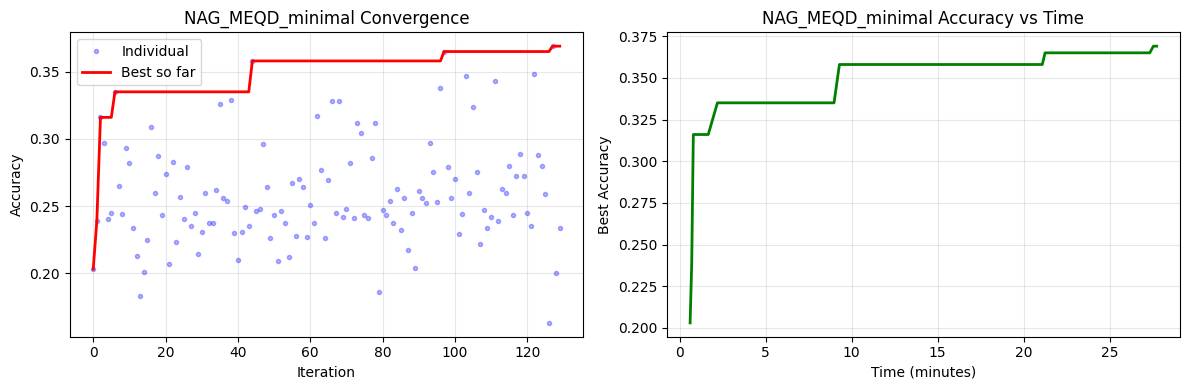

Plot saved to ./NAS_Comparison_Results/NAG_MEQD_minimal_plots.png


In [23]:
# Generate convergence plots
tracker.plot_convergence()

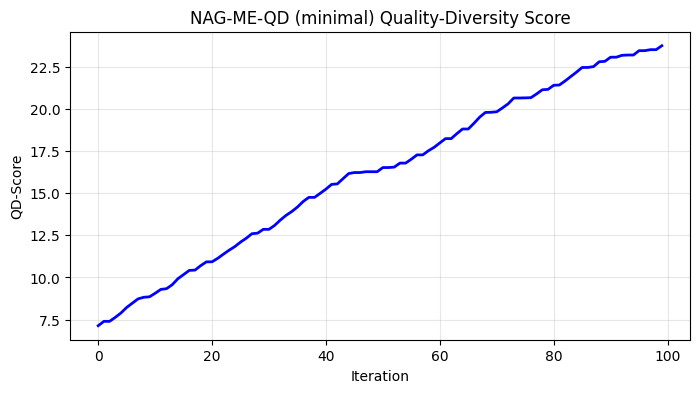

In [24]:
# Additional visualization: QD-Score over time
if tracker.history:
    qd_scores = [h.get('qd_score', 0) for h in tracker.history if 'qd_score' in h]
    if qd_scores:
        plt.figure(figsize=(8, 4))
        plt.plot(qd_scores, 'b-', linewidth=2)
        plt.xlabel('Iteration')
        plt.ylabel('QD-Score')
        plt.title(f'NAG-ME-QD ({EVAL_MODE}) Quality-Diversity Score')
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, f'NAG_MEQD_{EVAL_MODE}_qd_score.png'), dpi=150, bbox_inches='tight')
        plt.show()

---
## 20. Final Summary

In [25]:
print("\n" + "="*70)
print("NAG-ME-QD EXPERIMENT COMPLETE")
print("="*70)
print(f"\nEvaluation Mode: {EVAL_MODE}")
print(f"Best Accuracy: {tracker.best_accuracy:.4f}")
print(f"Total Architectures Evaluated: {tracker.total_architectures_evaluated}")
print(f"Search Time: {(time.time() - tracker.start_time)/3600:.2f} hours")
print(f"\nMAP-Elites Statistics:")
print(f"  Elites Discovered: {final_stats['num_elites']}")
print(f"  Grid Coverage: {final_stats['coverage']*100:.1f}%")
print(f"  QD-Score: {final_stats['qd_score']:.2f}")
print(f"\nAll results saved to: {OUTPUT_DIR}")
print("="*70)


NAG-ME-QD EXPERIMENT COMPLETE

Evaluation Mode: minimal
Best Accuracy: 0.7491
Total Architectures Evaluated: 130
Search Time: 2.08 hours

MAP-Elites Statistics:
  Elites Discovered: 89
  Grid Coverage: 0.1%
  QD-Score: 23.77

All results saved to: ./NAS_Comparison_Results


In [26]:
# List saved files
print("\nSaved files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if 'NAG_MEQD' in f or 'nag_meqd' in f:
        fpath = os.path.join(OUTPUT_DIR, f)
        size = os.path.getsize(fpath) / 1024
        print(f"  {f} ({size:.1f} KB)")


Saved files:
  NAG_MEQD_minimal_checkpoint.json (0.1 KB)
  NAG_MEQD_minimal_comparison.csv (0.1 KB)
  NAG_MEQD_minimal_history.json (36.7 KB)
  NAG_MEQD_minimal_mapelites_stats.json (0.1 KB)
  NAG_MEQD_minimal_plots.png (72.3 KB)
  NAG_MEQD_minimal_qd_score.png (40.0 KB)
  NAG_MEQD_minimal_results.json (2.7 KB)
  NAG_MEQD_minimal_trained_archs.json (0.8 KB)
  nag_meqd_top1_model.pth (190.3 KB)
  nag_meqd_top2_model.pth (144.5 KB)
  nag_meqd_top3_model.pth (262.6 KB)
  nag_meqd_top4_model.pth (625.5 KB)
